# Chapter 45: Metric Learning and ArcFace

**How much does the angular margin improve retrieval of unseen identities over a cross-entropy descriptor, and where does a larger margin stop helping?**

The margin m is one of the two head settings the chapter calls starting candidates rather than a universal winner. Sixteen paired trainings, each judged on query identities absent from training, show how the gain moves with m and when training becomes unreliable.

*Constructed data and a linear embedding; the sizes of these effects are properties of this generator, not a competition result.*

## The experiment

Constructed image features: 40 training identities with 6 images each, 32 features of which 8 carry identity and 24 are larger nuisance noise (pose and light), mixed by a random rotation. A linear embedding to 8 dimensions is trained with Adam in two ways from the same start: a plain linear cross-entropy head (the reference descriptor), and the chapter's ArcMarginHead with scale s = 16 and the control's margin m, whose gradients are written out in numpy. Retrieval is scored as MAP@5 on 40 further identities (3 gallery and 3 query images each), with every ranked identity listed once, as in the chapter's retrieval rule, averaged over 16 draws.

In [1]:
import numpy as np

from kaggle_companion.activities._common import clean

SEED = 45
DRAWS = 16                 # independent worlds; every estimate is a mean over draws and every gain is paired
D_SIG, D_NUIS = 8, 24      # identity-bearing dimensions and nuisance (pose, light) dimensions of the 32 image features
TRAIN_IDS, TRAIN_IMAGES = 40, 6
TEST_IDS = 40              # unseen identities, three gallery images and three query images each
SCALE = 16.0               # the chapter's s (feature scale); 16 is enough for 40 classes
EPOCHS = 300


def images(rotation, centers, ids, rng):
    """Image features: identity signal plus larger nuisance noise, mixed by a fixed rotation (a stand-in for backbone features)."""
    signal = centers[ids] + rng.normal(size=(len(ids), D_SIG))
    nuisance = 2.0 * rng.normal(size=(len(ids), D_NUIS))
    return np.column_stack([signal, nuisance]) @ rotation.T


def arc_logits(cos, labels, margin):
    """The chapter's ArcMarginHead: add the margin to the target angle, cos(theta + m), with the stability fix near pi - m."""
    sin = np.sqrt(1 - cos ** 2)
    shifted = np.where(cos > np.cos(np.pi - margin), cos * np.cos(margin) - sin * np.sin(margin),
                       cos - np.sin(np.pi - margin) * margin)
    out = cos.copy()
    out[np.arange(len(labels)), labels] = shifted[np.arange(len(labels)), labels]
    return SCALE * out


def loss_and_grads(params, X, labels, margin, head):
    """Softmax cross-entropy loss and its gradients. head 'ce': plain linear head. head 'arc': normalised features, prototypes and margin."""
    W, P = params
    n = len(X)
    E = X @ W
    onehot = np.eye(len(P))[labels]
    if head == "ce":
        logits = E @ P.T
    else:
        norm_e = np.linalg.norm(E, axis=1, keepdims=True)
        norm_p = np.linalg.norm(P, axis=1, keepdims=True)
        U, V = E / norm_e, P / norm_p
        cos = np.clip(U @ V.T, -1 + 1e-7, 1 - 1e-7)
        logits = arc_logits(cos, labels, margin)
    z = logits - logits.max(1, keepdims=True)
    prob = np.exp(z) / np.exp(z).sum(1, keepdims=True)
    loss = -np.mean(np.log(prob[np.arange(n), labels]))
    dlogits = (prob - onehot) / n
    if head == "ce":
        return loss, [X.T @ (dlogits @ P), dlogits.T @ E]
    sin = np.sqrt(1 - cos ** 2)
    stable = cos > np.cos(np.pi - margin)
    slope = np.where(stable, np.cos(margin) + cos * np.sin(margin) / sin, 1.0)
    dcos = SCALE * dlogits * np.where(onehot == 1, slope, 1.0)
    dU, dV = dcos @ V, dcos.T @ U
    dE = (dU - (dU * U).sum(1, keepdims=True) * U) / norm_e      # back through the length normalisation
    dP = (dV - (dV * V).sum(1, keepdims=True) * V) / norm_p
    return loss, [X.T @ dE, dP]


def train(X, labels, head, margin, seed):
    """Full-batch Adam on a linear 32 -> 8 embedding and the class prototypes. Returns the embedding matrix."""
    rng = np.random.default_rng(seed)
    params = [rng.normal(0, 1 / np.sqrt(X.shape[1]), (X.shape[1], D_SIG)), rng.normal(0, 1, (TRAIN_IDS, D_SIG))]
    m1 = [np.zeros_like(p) for p in params]
    m2 = [np.zeros_like(p) for p in params]
    for t in range(1, EPOCHS + 1):
        _, grads = loss_and_grads(params, X, labels, margin, head)
        for i, g in enumerate(grads):
            m1[i] = 0.9 * m1[i] + 0.1 * g
            m2[i] = 0.999 * m2[i] + 0.001 * g * g
            params[i] -= 0.02 * (m1[i] / (1 - 0.9 ** t)) / (np.sqrt(m2[i] / (1 - 0.999 ** t)) + 1e-8)
    return params[0]


def unit(a):
    return a / np.linalg.norm(a, axis=1, keepdims=True)


def map_at_5(query, query_ids, gallery, gallery_ids):
    """MAP@5 with one true identity per query. Ranked identities are listed once each, as in the chapter's retrieval rule."""
    similarity = unit(query) @ unit(gallery).T
    scores = []
    for sim, truth in zip(similarity, query_ids):
        ranked = []
        for j in np.argsort(-sim):
            if gallery_ids[j] not in ranked:
                ranked.append(gallery_ids[j])
            if len(ranked) == 5:
                break
        scores.append(1.0 / (ranked.index(truth) + 1) if truth in ranked else 0.0)
    return float(np.mean(scores))


def separation(query, query_ids, gallery, gallery_ids):
    """Mean cosine between same-identity pairs and between different-identity pairs."""
    sim = unit(query) @ unit(gallery).T
    same = query_ids[:, None] == gallery_ids[None, :]
    return float(sim[same].mean()), float(sim[~same].mean())


def run(margin):
    rng = np.random.default_rng(SEED)
    rows = {"ce": [], "arc": []}
    for draw in range(DRAWS):
        rotation, _ = np.linalg.qr(rng.normal(size=(D_SIG + D_NUIS, D_SIG + D_NUIS)))
        train_centers, test_centers = rng.normal(size=(TRAIN_IDS, D_SIG)) * 2, rng.normal(size=(TEST_IDS, D_SIG)) * 2
        y = np.repeat(np.arange(TRAIN_IDS), TRAIN_IMAGES)
        X = images(rotation, train_centers, y, rng)
        ids_seen, ids_unseen = np.repeat(np.arange(TRAIN_IDS), 3), np.repeat(np.arange(TEST_IDS), 3)
        sets = {"seen": (images(rotation, train_centers, ids_seen, rng), images(rotation, train_centers, ids_seen, rng), ids_seen),
                "unseen": (images(rotation, test_centers, ids_unseen, rng), images(rotation, test_centers, ids_unseen, rng), ids_unseen)}
        for name, head, m in (("ce", "ce", 0.0), ("arc", "arc", float(margin))):
            W = train(X, y, head, m, seed=draw)
            row = {}
            for split, (gallery, query, ids) in sets.items():
                row["map_" + split] = map_at_5(query @ W, ids, gallery @ W, ids)
            same, diff = separation(sets["unseen"][1] @ W, ids_unseen, sets["unseen"][0] @ W, ids_unseen)
            row.update({"same_cos": same, "diff_cos": diff})
            rows[name].append(row)
    mean = {n: {k: float(np.mean([r[k] for r in rs])) for k in rs[0]} for n, rs in rows.items()}
    gain = np.array([a["map_unseen"] - c["map_unseen"] for a, c in zip(rows["arc"], rows["ce"])])
    return clean({
        "margin": margin, "ce": mean["ce"], "arc": mean["arc"],
        "gain_unseen": gain.mean(), "gain_se": gain.std(ddof=1) / np.sqrt(DRAWS), "win_rate": float((gain > 0).mean()),
        "per_draw": {"ce": [r["map_unseen"] for r in rows["ce"]], "arc": [r["map_unseen"] for r in rows["arc"]]},
        "draws": DRAWS, "train_identities": TRAIN_IDS, "unseen_identities": TEST_IDS,
    })


## Measure it across the control

The control is **angular margin m (radians)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch45 import explain

VALUES = [0, 0.5, 0.8, 1.2]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                           0             0.5             0.8             1.2
Reference MAP@5, unseen                0.640           0.640           0.640           0.640
ArcFace MAP@5, unseen                  0.685           0.778           0.781           0.686
Paired gain (standard error)  +0.046 (0.012)  +0.139 (0.012)  +0.142 (0.014)  +0.047 (0.032)
ArcFace wins in draws                    81%            100%            100%             69%
ArcFace worst draw                     0.617           0.703           0.725           0.452
ArcFace MAP@5, seen                    0.676           0.771           0.778           0.679


## Look at it

The figure shows the default setting, angular margin m (radians) = 0.5.

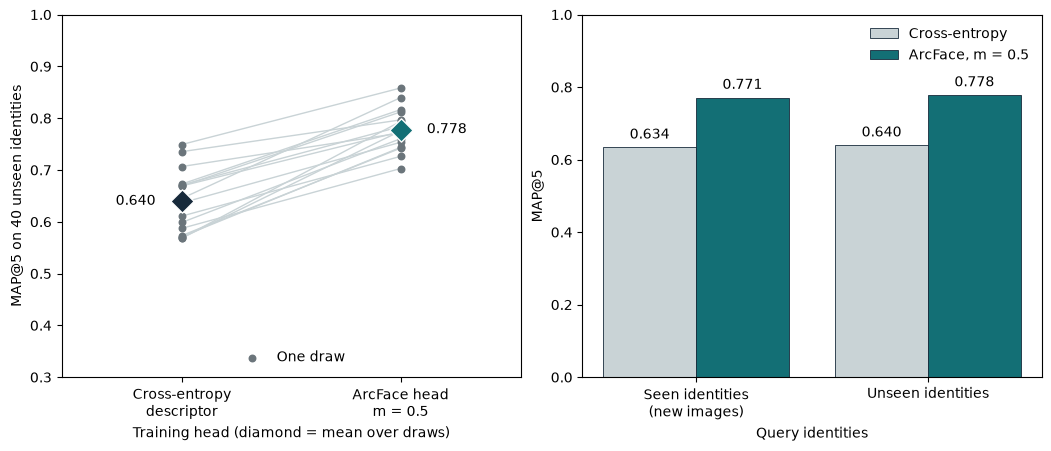

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch45 import draw, NCOLS, HEIGHT

DEFAULT = 0.5
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With margin 0.5, retrieval of unseen identities reaches MAP@5 0.778 against 0.640 for the cross-entropy descriptor: 0.778 - 0.640 = 0.138 (standard error 0.012, better in 100% of the 16 draws). The margin head is clearly better than the reference. On identities seen in training the margin head scores 0.771, close to its unseen score. The reference scores 0.634 on seen identities.

- Unseen-identity MAP@5, margin head minus reference: 0.778 - 0.640 = +0.138.
- Seen-identity MAP@5, margin head minus reference: 0.771 - 0.634 = +0.137.
- Paired standard error of the unseen gain: 0.012; the margin head wins in 100% of draws.
- Worst single draw of the margin head: 0.703 (reference worst: 0.569).

## Apply this to your competition

- Keep a cross-entropy descriptor as the reference and compare the margin head against it with the same identities, split and budget.
- Hold out whole identities for assessment, and list each identity once in the top five, as in the chapter's retrieval rule.
- Tune the margin on development identities over a few seeds, watching the worst seed as well as the mean, then freeze it.
- At inference use only the normalised descriptor: the margin is a training-time change and the target is unknown.

Book location: Chapter 45, Two Head Settings: Scale and Margin.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)